# Comp 388 | Assignment 7: LSTM vs GRU Performance

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
# Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)

# Flatten labels to 1D
y_train = y_train.squeeze()
y_test = y_test.squeeze()

# Combine so we can split 70/30 as requested
x_combined = np.concatenate([x_train, x_test], axis=0)
y_combined = np.concatenate([y_train, y_test], axis=0)

# Normalize
x_combined = x_combined.astype("float32") / 255.0

# 70/30 split
x_train, x_test, y_train, y_test = train_test_split(
    x_combined, y_combined, test_size=0.30, random_state=17, stratify=y_combined
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((49000, 28, 28), (21000, 28, 28), (49000,), (21000,))

## Build and Compare LSTM and GRU Models

In [9]:
import time

tf.keras.utils.set_random_seed(17)

SEQUENCE_LENGTH = 28
NUM_FEATURES = 28
NUM_CLASSES = 10
HIDDEN_UNITS = 100
LEARNING_RATE = 1e-4
BATCH_SIZE = 32
EPOCHS = 50

In [4]:
def build_lstm_model():
    model = keras.Sequential([
        keras.Input(shape=(SEQUENCE_LENGTH, NUM_FEATURES)),
        layers.LSTM(HIDDEN_UNITS),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="lstm_model")

    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_gru_model():
    model = keras.Sequential([
        keras.Input(shape=(SEQUENCE_LENGTH, NUM_FEATURES)),
        layers.GRU(HIDDEN_UNITS),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="gru_model")

    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def train_and_evaluate(model_builder, model_name):
    tf.keras.backend.clear_session()
    model = model_builder()

    start_time = time.perf_counter()
    history = model.fit(
        x_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )
    training_time = time.perf_counter() - start_time

    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

    print(f"{model_name} training time: {training_time:.2f} seconds")
    print(f"{model_name} test accuracy: {test_accuracy:.4f}")

    return {
        "name": model_name,
        "model": model,
        "history": history,
        "training_time": training_time,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
    }

In [5]:
lstm_results = train_and_evaluate(build_lstm_model, "LSTM")
gru_results = train_and_evaluate(build_gru_model, "GRU")

Epoch 1/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.1049 - loss: 2.3230
Epoch 2/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1205 - loss: 2.3193
Epoch 3/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1306 - loss: 2.3159
Epoch 4/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1384 - loss: 2.3128
Epoch 5/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1441 - loss: 2.3098
Epoch 6/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1472 - loss: 2.3070
Epoch 7/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1486 - loss: 2.3042
Epoch 8/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.1498 - loss: 2.3015
Epoch 9/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1512 - loss: 2.2989
Epoch 10/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1548 - loss: 2.2963
Epoch 11/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1602 - loss: 2.2937
Epoch 12/50
1532/1532 ━━━━━━

In [7]:
results = {
    "Model": [lstm_results["name"], gru_results["name"]],
    "Training Time (s)": [lstm_results["training_time"], gru_results["training_time"]],
    "Test Accuracy": [lstm_results["test_accuracy"], gru_results["test_accuracy"]],
}

for i, model_name in enumerate(results["Model"]):
    print(
        f"{model_name}: training time = {results['Training Time (s)'][i]:.2f} s, "
        f"test accuracy = {results['Test Accuracy'][i]:.4f}"
    )

LSTM: training time = 367.21 s, test accuracy = 0.3395
GRU: training time = 372.69 s, test accuracy = 0.1888


We see that LSTM has a barely has a faster training time and overall a much better accuracy.

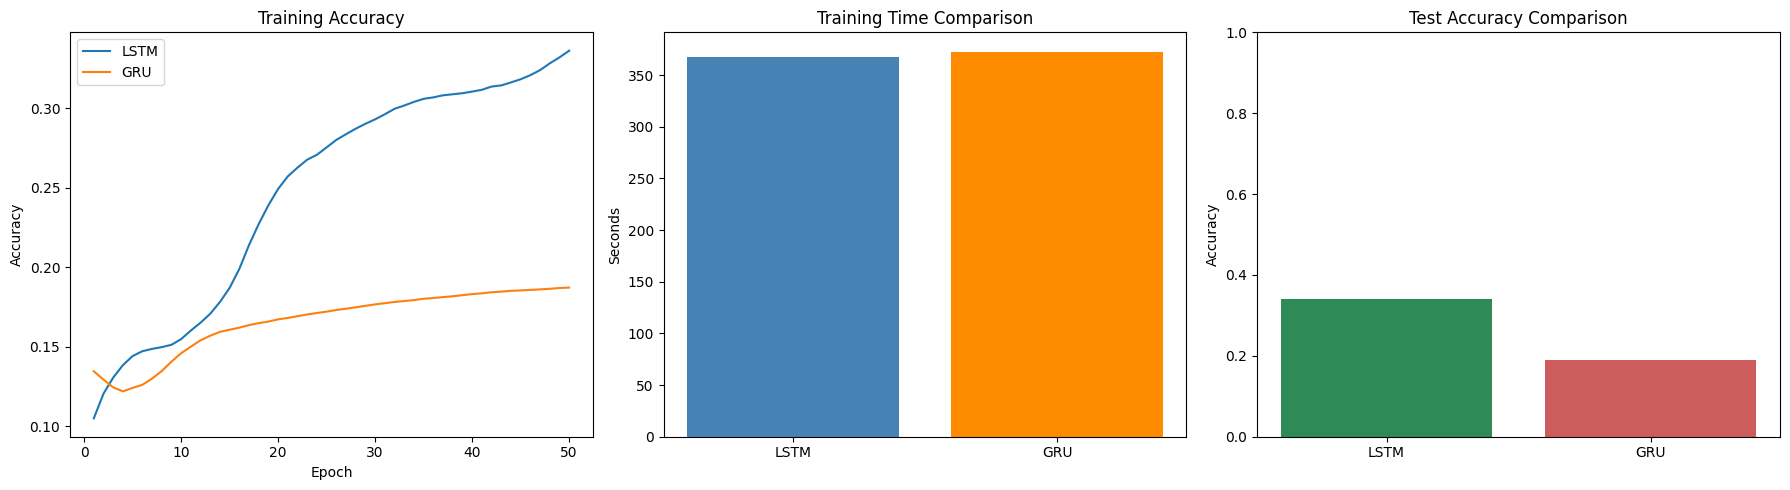

In [8]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, lstm_results["history"].history["accuracy"], label="LSTM")
plt.plot(epochs, gru_results["history"].history["accuracy"], label="GRU")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 3, 2)
plt.bar(results["Model"], results["Training Time (s)"], color=["steelblue", "darkorange"])
plt.title("Training Time Comparison")
plt.ylabel("Seconds")

plt.subplot(1, 3, 3)
plt.bar(results["Model"], results["Test Accuracy"], color=["seagreen", "indianred"])
plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

When plotting the accuracy we see that the GRU was starting to level out, indicating a stagnation in the implementation. Where the LSTM is still trending up even after the 50 epochs indicating with more epochs or a higher learning rate it possibly could have had an even higher accuracy

We see that the training time comparison is basically the same and the test accuracy shows LSTM is performing alost twice as good compared to GRU.